# Tier 5 · Notebook 23 — Variational Autoencoders (VAE)

> **Goal:** build a **generative** model — one that *creates* new data rather than classifying it. We derive the two ideas that make VAEs work — the **reparameterization trick** (to backprop through random sampling) and the **ELBO** (the loss) — implement a VAE from scratch, and *visualize its learned latent space* on MNIST.

**From classifying to generating.** Everything so far mapped inputs to outputs (classify, predict next token). A **generative model** learns the data distribution $p(x)$ itself, so you can **sample new examples** — new digits, faces, molecules. The VAE's approach: learn to compress each image into a small **latent code** $z$ (a point in, say, 2-D space) via an **encoder**, and to reconstruct the image from $z$ via a **decoder** — while forcing the latent codes to fill a smooth, known distribution (a Gaussian). Then to *generate*, you just sample $z$ from that Gaussian and decode it. The magic is making the whole thing trainable end-to-end despite a *random sampling* step in the middle.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets, transforms
tf = transforms.ToTensor()
train_ds = datasets.MNIST("./data", train=True, download=True, transform=tf)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tf)
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=256, shuffle=True)
print("device:", device, "| MNIST loaded")


  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 98.3k/9.91M [00:00<00:14, 700kB/s]

  3%|▎         | 328k/9.91M [00:00<00:07, 1.35MB/s]

  8%|▊         | 754k/9.91M [00:00<00:04, 2.03MB/s]

 14%|█▍        | 1.38M/9.91M [00:00<00:02, 3.31MB/s]

...

 83%|████████▎ | 1.38M/1.65M [00:00<00:00, 2.92MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.03MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 2.28MB/s]

device: cuda | MNIST loaded


## 0. The reparameterization trick

The VAE encoder outputs a *distribution* over latents: $q(z|x) = \mathcal{N}(\mu, \sigma^2)$, i.e. a mean $\mu$ and variance $\sigma^2$ per latent dimension. To train, we must **sample** $z \sim \mathcal{N}(\mu, \sigma^2)$ and decode it — but *you can't backpropagate through a random sample* (the sampling operation has no gradient w.r.t. $\mu, \sigma$).

**The trick:** move the randomness *outside* the gradient path. Instead of sampling $z$ directly, sample a fixed noise $\varepsilon \sim \mathcal{N}(0,1)$ and compute
$$z = \mu + \sigma \odot \varepsilon.$$
Now $z$ is a *deterministic, differentiable* function of $\mu$ and $\sigma$ (with $\varepsilon$ just a constant input), so gradients flow to the encoder. Same distribution for $z$, but now trainable. This one reparameterization is what makes VAEs (and much of modern generative modeling) possible.


In [2]:
# demonstrate: reparameterized sampling has the same distribution but IS differentiable
mu = torch.tensor(2.0, requires_grad=True); log_sigma = torch.tensor(0.5, requires_grad=True)
eps = torch.randn(10000)
z = mu + torch.exp(log_sigma) * eps                       # reparameterized samples
print(f"sampled z: mean {z.mean():.3f} (target {mu.item()}), std {z.std():.3f} (target {torch.exp(log_sigma).item():.3f})")
# gradient of a function of z flows back to mu and log_sigma:
z.mean().backward()
print(f"d(mean z)/d(mu) = {mu.grad:.3f} (should be ~1)   -- gradients flow through the sampling! ✅")


sampled z: mean 1.982 (target 2.0), std 1.652 (target 1.649)
d(mean z)/d(mu) = 1.000 (should be ~1)   -- gradients flow through the sampling! ✅


## 1. The ELBO — the VAE loss

We want to maximize the data likelihood $p(x)$, but it's intractable. Instead we maximize a tractable lower bound, the **Evidence Lower BOund (ELBO)**:
$$\log p(x) \;\ge\; \underbrace{\mathbb{E}_{q(z|x)}[\log p(x|z)]}_{\text{reconstruction}} \;-\; \underbrace{\mathrm{KL}\big(q(z|x)\,\|\,p(z)\big)}_{\text{regularizer}}.$$
Two terms with clear jobs:
- **Reconstruction**: decode $z$ and it should match the input $x$ (here: binary cross-entropy between the decoded pixels and the original). "Don't lose information."
- **KL to the prior** $p(z)=\mathcal{N}(0,I)$: push each encoded distribution $q(z|x)$ toward a standard Gaussian. "Keep the latent space smooth and centered so we can sample from it." For two Gaussians this KL has a **closed form**:
$$\mathrm{KL}\big(\mathcal{N}(\mu,\sigma^2)\,\|\,\mathcal{N}(0,1)\big) = -\tfrac12\sum\big(1 + \log\sigma^2 - \mu^2 - \sigma^2\big).$$
We *minimize* the negative ELBO (reconstruction loss + KL). The tension between the two terms is the whole story: reconstruction wants distinct codes per image; the KL wants everything squished to $\mathcal{N}(0,I)$. The balance yields a smooth, sample-able latent space.


In [3]:
class VAE(nn.Module):
    def __init__(self, latent=2):     # 2-D latent so we can VISUALIZE it
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 400), nn.ReLU(), nn.Linear(400, 200), nn.ReLU())
        self.fc_mu = nn.Linear(200, latent); self.fc_logvar = nn.Linear(200, latent)
        self.dec = nn.Sequential(nn.Linear(latent, 200), nn.ReLU(), nn.Linear(200, 400), nn.ReLU(),
                                 nn.Linear(400, 784), nn.Sigmoid())
    def encode(self, x): h = self.enc(x); return self.fc_mu(h), self.fc_logvar(h)
    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar); return mu + std*torch.randn_like(std)    # the trick
    def forward(self, x):
        mu, logvar = self.encode(x); z = self.reparam(mu, logvar)
        return self.dec(z), mu, logvar

def elbo_loss(recon, x, mu, logvar):
    bce = F.binary_cross_entropy(recon, x, reduction="sum")                   # reconstruction
    kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())             # KL to N(0,I), closed form
    return (bce + kl) / x.size(0), bce/x.size(0), kl/x.size(0)

vae = VAE(latent=2).to(device); opt = torch.optim.Adam(vae.parameters(), 1e-3)
print(f"VAE with 2-D latent, {sum(p.numel() for p in vae.parameters()):,} params")


VAE with 2-D latent, 790,388 params


## 2. Train the VAE


In [4]:
for epoch in range(12):
    tot=rec=klt=0
    for x,_ in train_ld:
        x = x.view(-1,784).to(device)
        recon, mu, logvar = vae(x); loss, b, k = elbo_loss(recon, x, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
        tot+=loss.item(); rec+=b.item(); klt+=k.item()
    if epoch%3==0 or epoch==11:
        n=len(train_ld); print(f"epoch {epoch:2d}  ELBO loss {tot/n:.1f}  (recon {rec/n:.1f} + KL {klt/n:.2f})")
print("✅ VAE trained")


epoch  0  ELBO loss 198.5  (recon 194.9 + KL 3.59)


epoch  3  ELBO loss 156.8  (recon 151.3 + KL 5.55)


epoch  6  ELBO loss 150.9  (recon 145.0 + KL 5.92)


epoch  9  ELBO loss 147.4  (recon 141.2 + KL 6.16)


epoch 11  ELBO loss 145.5  (recon 139.3 + KL 6.26)
✅ VAE trained


## 3. Reconstructions and fresh samples

Two tests of a generative model: (a) **reconstruct** held-out inputs (does the autoencoder preserve them?), and (b) **generate** brand-new digits by sampling $z\sim\mathcal{N}(0,I)$ and decoding — data that never existed.


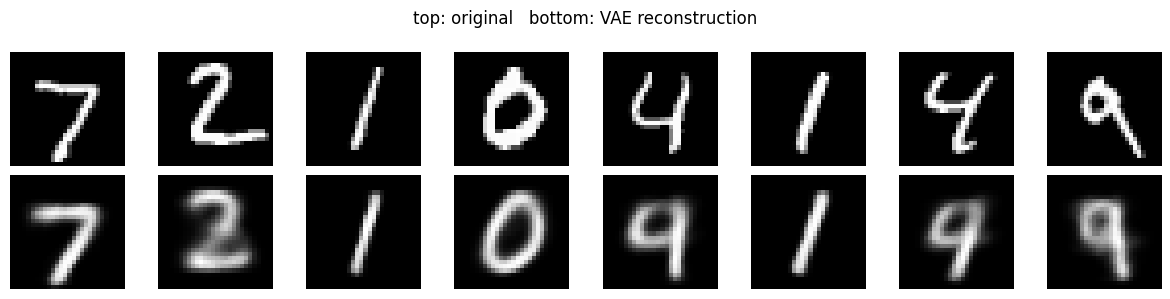

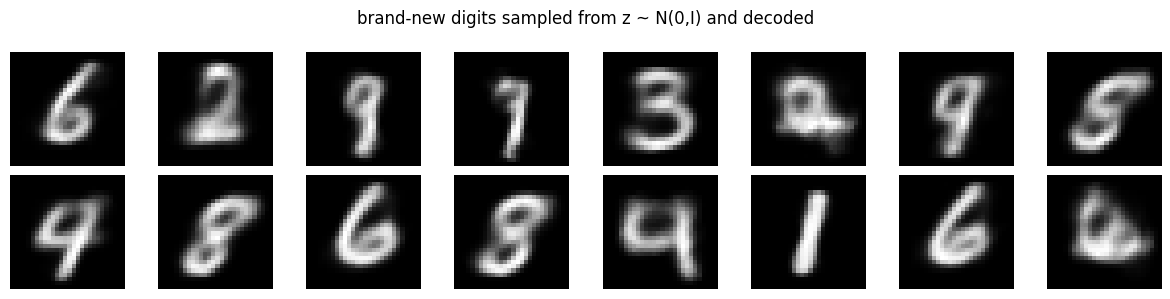

In [5]:
vae.eval()
# (a) reconstructions
xb = torch.stack([test_ds[i][0] for i in range(8)]).view(-1,784).to(device)
with torch.no_grad(): recon,_,_ = vae(xb)
fig, ax = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    ax[0,i].imshow(xb[i].cpu().view(28,28), cmap="gray"); ax[0,i].axis("off")
    ax[1,i].imshow(recon[i].cpu().view(28,28), cmap="gray"); ax[1,i].axis("off")
ax[0,0].set_ylabel("input"); ax[1,0].set_ylabel("recon")
fig.suptitle("top: original   bottom: VAE reconstruction"); plt.tight_layout(); plt.show()

# (b) samples from the prior
with torch.no_grad():
    zs = torch.randn(16, 2).to(device); gen = vae.dec(zs).cpu()
fig, ax = plt.subplots(2, 8, figsize=(12, 3))
for i,a in enumerate(ax.ravel()): a.imshow(gen[i].view(28,28), cmap="gray"); a.axis("off")
fig.suptitle("brand-new digits sampled from z ~ N(0,I) and decoded"); plt.tight_layout(); plt.show()


**What to notice.** Reconstructions (top block) recover the input digits — a bit blurry (a known VAE trait: the Gaussian decoder + averaging over the posterior smooths details, and a 2-D latent is a tight bottleneck), but recognizable. The **samples** (bottom) are *entirely new digits* the model invented by sampling random latent points — proof it learned a generative distribution, not just memorized. The blurriness is exactly what GANs (next notebook) and diffusion (NB25) improve on.


## 4. Visualize the latent space — the payoff of a 2-D latent

Because we used a **2-D latent**, we can *see* the entire learned representation. Two views:
1. **Encode** the test set and scatter each digit's latent $\mu$, colored by its true label — do similar digits cluster?
2. **Decode a grid** of latent points spanning the space — does the manifold vary smoothly from one digit to another?


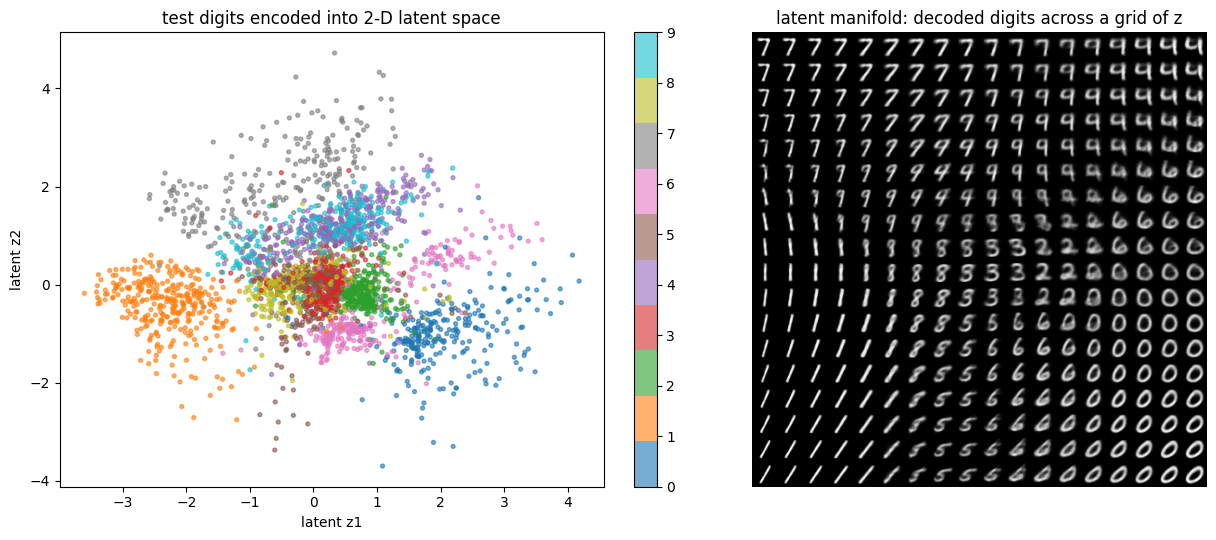

In [6]:
# (1) encode test set -> 2D latent scatter, colored by label
xs = torch.stack([test_ds[i][0] for i in range(3000)]).view(-1,784).to(device)
ys = np.array([test_ds[i][1] for i in range(3000)])
with torch.no_grad(): mus,_ = vae.encode(xs); mus = mus.cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
sc = ax[0].scatter(mus[:,0], mus[:,1], c=ys, cmap="tab10", s=8, alpha=0.6)
ax[0].set_title("test digits encoded into 2-D latent space"); ax[0].set_xlabel("latent z1"); ax[0].set_ylabel("latent z2")
plt.colorbar(sc, ax=ax[0], ticks=range(10), fraction=0.046)

# (2) decode a grid over the latent space
grid = 18; span = 2.5
gx = np.linspace(-span, span, grid); gy = np.linspace(span, -span, grid)
canvas = np.zeros((28*grid, 28*grid))
with torch.no_grad():
    for i,yv in enumerate(gy):
        for j,xv in enumerate(gx):
            img = vae.dec(torch.tensor([[xv,yv]],dtype=torch.float32,device=device)).cpu().view(28,28)
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img
ax[1].imshow(canvas, cmap="gray"); ax[1].axis("off")
ax[1].set_title("latent manifold: decoded digits across a grid of z")
plt.tight_layout(); plt.show()


**What to notice.** Left: the encoder organized the digits into **clusters by class** in a smooth 2-D space — *without ever seeing the labels* (the VAE is unsupervised; colors are just for us). The KL-to-prior term is what packed them near the origin into a continuous blob rather than scattered islands. Right: decoding a grid of latent points shows the manifold **morphing smoothly** between digit types — a 4 gradually becoming a 9, a 3 into an 8. That smoothness and continuity is the defining property of a good latent space: nearby codes → similar images, so you can *interpolate* and *sample* meaningfully. This picture is the classic "what did the VAE learn" visualization.

## 5. What you built / learned
- The **reparameterization trick**: $z=\mu+\sigma\varepsilon$ makes sampling differentiable (verified gradients flow).
- The **ELBO**: reconstruction (decode ≈ input) − KL (latents ≈ $\mathcal{N}(0,I)$); the closed-form Gaussian KL.
- A working **VAE** that reconstructs *and* generates new MNIST digits.
- **Latent-space visualization**: class clustering (unsupervised) and a smooth decoded manifold.

## 6. Exercises
1. **β-VAE.** Weight the KL term by β; sweep it. Large β → more disentangled but blurrier; small β → sharper but less structured. Show the tradeoff.
2. **Higher latent dim.** Use a 16-D latent; sharper samples, but you lose the 2-D viz. Compare reconstruction quality.
3. **Posterior collapse.** Make the decoder very powerful; watch the KL go to ~0 (the model ignores z). Why, and how to fix (KL annealing, free bits)?
4. **Interpolate.** Encode two digits, interpolate z linearly, decode the path — smooth morph?
5. **Conditional VAE.** Feed the label to encoder+decoder; now you can generate a *specified* digit.
6. **Convolutional VAE.** Replace the MLP with conv encoder/decoder; sharper images.

## 7. Interview / residency framing
- *"What is the reparameterization trick and why?"* → write $z=\mu+\sigma\varepsilon$ so sampling is differentiable w.r.t. $\mu,\sigma$; you can't backprop through raw sampling.
- *"What is the ELBO?"* → a tractable lower bound on $\log p(x)$: reconstruction term − KL(q(z|x)‖p(z)); maximize it (minimize negative).
- *"What does the KL term do?"* → regularizes latents toward $\mathcal{N}(0,I)$ so the space is smooth and sample-able; trades off against reconstruction.
- *"Why are VAE samples blurry?"* → Gaussian likelihood + averaging over the posterior; the model hedges. GANs/diffusion fix this.
- *"VAE vs GAN vs diffusion?"* → VAE: explicit latent + likelihood bound, stable, blurry; GAN: adversarial, sharp, unstable; diffusion: iterative denoising, sharp + stable, slower.

## 📚 References & papers

This notebook reproduces / builds on:

- **Auto-Encoding Variational Bayes (VAE)** — Kingma & Welling (2013), arXiv:1312.6114. The paper this notebook implements.
- **Stochastic Backpropagation and Approximate Inference in Deep Generative Models** — Rezende, Mohamed & Wierstra (2014), arXiv:1401.4082. Concurrent reparameterization.
- **β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework** — Higgins et al. (2017). Disentanglement via KL weighting.

---
**Next:** *Tier 5 · Notebook 24 — GANs from scratch*: the adversarial game between a generator and a discriminator — sharper samples, and the notorious training instability (mode collapse) shown live.
